In [2]:
from openpyxl import Workbook
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
import itertools
from datetime import datetime
import joblib
from scipy import stats
from sklearn.decomposition import PCA
#from tqdm.notebook import tqdm
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from matplotlib import font_manager as fm
import openpyxl
import shutil
import subprocess
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import importlib
import multiprocessing
import shutil
import tifftools


#status = subprocess.check_output('zip /disk2/2024_mice/heatmap.zip /disk2/2024_mice/heatmap_*', shell=True)
#status = subprocess.check_output('cp /disk2/2024_mice/heatmap.zip output', shell=True)
#print(status)

2025-05-30 14:28:38,707[INFO]: cfos init begin
2025-05-30 14:28:38,710[INFO]: Naive-Control sheet loaded from: C:/workkspace/brainrender/web_cfos/projects/cfos-gradienttest_cleanedup\df_sheet_Naive-Control.csv'
2025-05-30 14:28:38,725[INFO]: Naive_Egfr-null sheet loaded from: C:/workkspace/brainrender/web_cfos/projects/cfos-gradienttest_cleanedup\df_sheet_Naive_Egfr-null.csv'
2025-05-30 14:28:38,741[INFO]: TMT_Control sheet loaded from: C:/workkspace/brainrender/web_cfos/projects/cfos-gradienttest_cleanedup\df_sheet_TMT_Control.csv'
2025-05-30 14:28:38,755[INFO]: TMT_Egfr-null sheet loaded from: C:/workkspace/brainrender/web_cfos/projects/cfos-gradienttest_cleanedup\df_sheet_TMT_Egfr-null.csv'
2025-05-30 14:28:38,780[INFO]: not_matched_tg_numbers: 211, 747, 733, 985, 211, 747, 733, 985, 211, 249, 747, 733, 985
2025-05-30 14:28:38,783[INFO]: tg_number_common: 460, 21, 646, 529, 808, 737, 850, 156, 349, 279, 378, 70, 150, 471, 562, 798, 426, 991, 350, 359, 76, 269, 663, 720, 847, 151, 53

{'TG_number': 'Sheets contain different TG numbers as follows: 211, 747, 733, 985, 211, 747, 733, 985, 211, 249, 747, 733, 985. Nevertheless, you can do analysis using common 569 of TG numbers.'}


c:\workkspace\brainrender\cfos\cfos_util.py:580: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  #plt.tight_layout()
2025-05-30 14:28:39,322[INFO]: Naive_Egfr-null
c:\workkspace\brainrender\cfos\cfos_util.py:580: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  #plt.tight_layout()
2025-05-30 14:28:39,527[INFO]: TMT_Control
c:\workkspace\brainrender\cfos\cfos_util.py:580: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  #plt.tight_layout()
2025-05-30 14:28:39,725[INFO]: TMT_Egfr-null
c:\workkspace\brainrender\cfos\cfos_util.py:580: UserWarning: No artists with labels found to put in legend.  Note that artists whose label st


'\n\ncfos.build_group1_and_group2(cfos.group_names[0],cfos.group_names[1], load_from_files = 
False)\n#cfos.build_group1_and_group2(cfos.group_names[1],cfos.group_names[2], load_from_files = True)\n\ndf_fold =
cfos_stat.cal_fold(cfos, cfos.df_by_two_group_and_color, cfos.group_names[0], cfos.group_names[1], result_filename 
= project_dir+"/fold.csv")\n\n\n\n\nparams = cfos_util.Cfos_params()\n\n\nparams.group1_name = 
\'TMT_Egfr-null\'\nparams.group2_name = \'TMT_Control\'\nparams.pairwiseCompareMethod = 
\'permutation-test\'\nparams.multipleCompareCorrectionMethod = \'FDR\'\nparams.fdr_alpha = 0.05\n\nparams.pvalue_th
= 0.1\nparams.fold_up = 1.5\nparams.fold_down = 0.67\nparams.color = \'CFOShigh\'\nparams.dataname = 
\'cfostest\'\nparams.num_of_imgs_in_brain_heatmap = 8\nparams.dist_label = False\n\nstat_name = 
params.stat_test_name()\nfilename_pairwiseCompare= 
f\'{project_dir}/{stat_name}/pairwise_{params.pairwiseCompareMethod}.csv\'\n\nos.makedirs(project_dir+"/"+stat_name
exist

<Figure size 640x480 with 0 Axes>

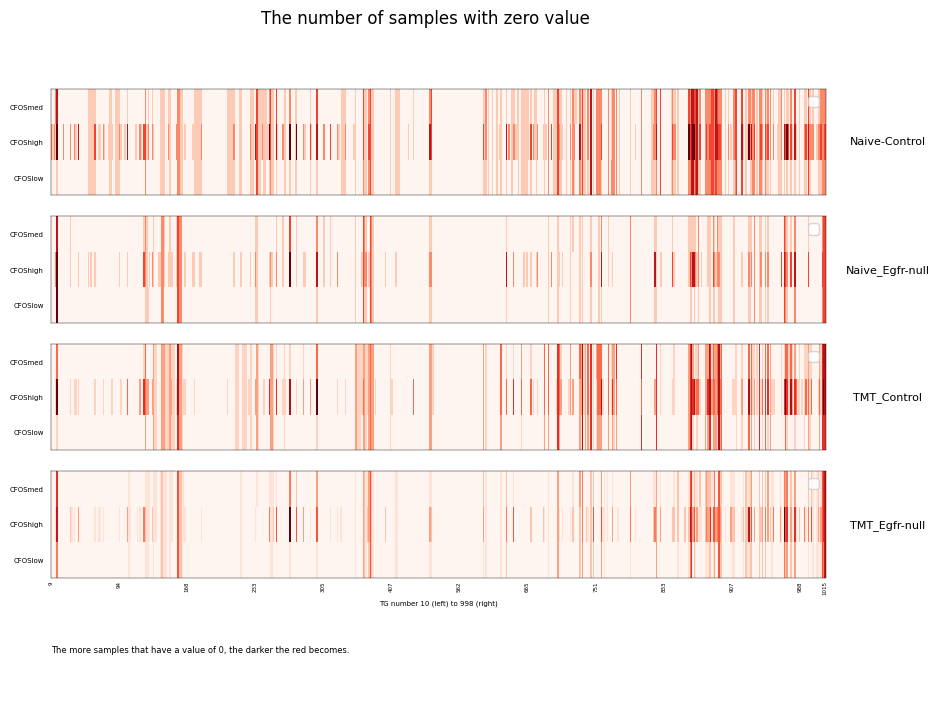

In [17]:
import cfos_util
importlib.reload(cfos_util)

import cfos_stat
importlib.reload(cfos_stat)
import cfos_brainheatmap
importlib.reload(cfos_brainheatmap)
output_dir = "output"
#try:
#    shutil.rmtree(output_dir)
#except:
#    pass
#try:
#    os.mkdir(output_dir)
#except:
#    pass  
filename = 'C:/workkspace/brainrender/cfos/resources/cfos-gradienttest_cleanedup.xlsx'
#project_dir = 'C:/workkspace/brainrender/web_cfos/brain/public/projects/output'
DATA_FOLDER = 'C:/workkspace/brainrender/web_cfos/projects'
project_dir = DATA_FOLDER + "/cfos-gradienttest_cleanedup"
cfos = cfos_util.Cfos(filename, project_dir, load_from_files=True)
#cfos.build_exp_veh()
#print(cfos.preprocess_summary())
#cfos.gen_zero_value_heatmap_color(output_filename=project_dir+"/regions_with_zero_values.png")

print(cfos.validation_report())

filename = f'{project_dir}/regions_with_zero_values.png'
cfos.gen_zero_value_heatmap_color(filename)

'''

cfos.build_group1_and_group2(cfos.group_names[0],cfos.group_names[1], load_from_files = False)
#cfos.build_group1_and_group2(cfos.group_names[1],cfos.group_names[2], load_from_files = True)

df_fold = cfos_stat.cal_fold(cfos, cfos.df_by_two_group_and_color, cfos.group_names[0], cfos.group_names[1], result_filename = project_dir+"/fold.csv")




params = cfos_util.Cfos_params()


params.group1_name = 'TMT_Egfr-null'
params.group2_name = 'TMT_Control'
params.pairwiseCompareMethod = 'permutation-test'
params.multipleCompareCorrectionMethod = 'FDR'
params.fdr_alpha = 0.05

params.pvalue_th = 0.1
params.fold_up = 1.5
params.fold_down = 0.67
params.color = 'CFOShigh'
params.dataname = 'cfostest'
params.num_of_imgs_in_brain_heatmap = 8
params.dist_label = False

stat_name = params.stat_test_name()
filename_pairwiseCompare= f'{project_dir}/{stat_name}/pairwise_{params.pairwiseCompareMethod}.csv'

os.makedirs(project_dir+"/"+stat_name, exist_ok=True)

df_pairwise_test = cfos_stat.cal_pvalue(cfos, cfos.df_by_two_group_and_color, params.pairwiseCompareMethod, 
                                        filename_pairwiseCompare, sigle_core_mode = False, test_mode = False)
#df_pvalue_ttest = cfos_stat.cal_pvalue(cfos,cfos.df_by_two_group_and_color, 't_test',filename_pvalue_ttest)

filename_multiplecorrection = f'{project_dir}/{stat_name}/multiplecorrection_{params.multipleCompareCorrectionMethod}.csv'


df_fdr_permutation_test = cfos_stat.cal_fdr(cfos, df_pairwise_test,  _alpha = params.fdr_alpha, result_filename=filename_multiplecorrection)

color_2_dict_up, color_2_dict_down, df_sig_region_fold= cfos_brainheatmap.build_dict(cfos, df_fold, df_fdr_permutation_test, params)

cfos_brainheatmap.gen_brain_heatmap(cfos,project_dir+"/"+stat_name, df_fdr_permutation_test, cfos.color_list_full, color_2_dict_up,color_2_dict_down, params, single_core_mode = False)

'''

In [ ]:
df_fdr_permutation_test.set_index('Region ID').loc['997']['SignalX']

np.float64(0.9057997766861572)

2025-05-28 05:38:22,902[INFO]: build_dict begin


: 

In [15]:
_color = "SST"
_df_total_veh = cfos.df_mean_cor_sag.query(f'color=="{_color}" and veh_exp == 0 ').drop(['veh_exp','color','sample_id'],axis=1).copy()
_df_total_exp = cfos.df_mean_cor_sag.query(f'color=="{_color}" and veh_exp == 1 ').drop(['veh_exp','color','sample_id'],axis=1).copy()
_df_total_exp_veh = pd.concat([_df_total_exp.mean(axis=0), _df_total_veh.mean(axis=0)], axis=1)
_df_total_exp_veh.index


Index(['0', '997', '8', '567', '688', '695', '315', '184', '68', '667',
       ...
       '11', '18', '25', '34', '43', '49', '57', '65', '624', '304325711'],
      dtype='object', length=1328)

In [4]:
_df_total_veh

,0,997,8,567,688,695,315,184,68,667,...,11,18,25,34,43,49,57,65,624,304325711
14,0.0,0.010493,0.0,0.0,0.0,0.0,0.0,0.0,0.004551,0.009590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,0.0,0.009856,0.0,0.0,0.0,0.0,0.0,0.0,0.008096,0.007644,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,0.0,0.003903,0.0,0.0,0.0,0.0,0.0,0.0,0.002714,0.008490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91,0.0,0.007341,0.0,0.0,0.0,0.0,0.0,0.0,0.010856,0.014753,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,0.0,0.012161,0.0,0.0,0.0,0.0,0.0,0.0,0.012787,0.022714,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113,0.0,0.004554,0.0,0.0,0.0,0.0,0.0,0.0,0.009180,0.006578,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
pd.concat([cfos.df_exp.drop(['TG number','Region ID','Region name'] ,axis=1),cfos.df_veh.drop(['TG number','Region name'] ,axis=1)], axis=1)

,A0244_cor_SST,A0244_sag_SST,A0242_cor_SST,A0242_sag_SST,1049_cor_SST,1049_sag_SST,0644_cor_SST,0644_sag_SST,0654_cor_SST,0654_sag_SST,...,A0247_cor_cfos total,A0247_sag_cfos total,A0249_cor_cfos total,A0249_sag_cfos total,0651_cor_cfos total,0651_sag_cfos total,0653_cor_cfos total,0653_sag_cfos total,0656_cor_cfos total,0656_sag_cfos total
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.006102,0.001988,0.004848,0.001346,0.036548,0.005867,0.004486,0.007119,0.0082,0.004544,...,0.006971,0.014907,0.015803,0.009787,0.006132,0.004957,0.008268,0.003865,0.006348,0.005524
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1324,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1325,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1326,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
cfos.df_mean_cor_sag

,sample_id,color,veh_exp,0,997,8,567,688,695,315,...,11,18,25,34,43,49,57,65,624,304325711
0,0644,PV,1,0.0,0.002148,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0644,PV-cfos,1,0.0,0.000634,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0644,PV/cfos fraction,1,0.0,15.324702,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0644,SST,1,0.0,0.005803,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0644,SST-PV,1,0.0,0.000335,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,A0249,SST-PV/cfos fraction,0,0.0,40.176219,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117,A0249,SST-cfos,0,0.0,0.000795,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
118,A0249,SST/cfos fraction,0,0.0,15.767347,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119,A0249,cfos,0,0.0,0.010702,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
cfos.df_total.columns[:-4]

Index(['Unnamed: 0', '0', '997', '8', '567', '688', '695', '315', '184', '68',
       ...
       '11', '18', '25', '34', '43', '49', '57', '65', '624', '304325711'],
      dtype='object', length=1329)

In [15]:
#print(cfos.df_exp['A0245_cor_SST-cfos'] /(cfos.df_exp['A0245_cor_SST-cfos']  + cfos.df_exp['A0245_cor_SST'])*100)
#print(cfos.df_exp['A0245_cor_SST/cfos fraction'])

print(cfos.df_exp['A0245_cor_SST-PV-cfos'] /(cfos.df_exp['A0245_cor_SST-PV-cfos']  + cfos.df_exp['A0245_cor_SST-PV'])*100)
print(cfos.df_exp['A0245_cor_SST-PV/cfos fraction'])


0            NaN
1       4.853129
2            NaN
3            NaN
4            NaN
          ...   
1323         NaN
1324         NaN
1325         NaN
1326         NaN
1327         NaN
Length: 1328, dtype: float64
0       0.000000
1       4.853129
2       0.000000
3       0.000000
4       0.000000
          ...   
1323    0.000000
1324    0.000000
1325    0.000000
1326    0.000000
1327    0.000000
Name: A0245_cor_SST-PV/cfos fraction, Length: 1328, dtype: float64


In [10]:
import itertools

for element in itertools.product([1, 2, 3], ['a', 'b']):
    print(str(element[0])+"_"+element[1])

1_a
1_b
2_a
2_b
3_a
3_b


In [66]:
_df_sst_mean,  _data_list = cfos.mean_value_by_color(cfos.region_ids_with_NOT_all_zero_exp_veh)
_df_sst_mean.to_csv('output/mean_value_by_color.csv')


In [65]:
color_ids  = [c for c in _df_fdr_t_test.columns if c not in ['TG number','sample_id','color','veh_exp','Region Name','Region ID']]


_df_temp = df_pvalue_permutation_test[color_ids]
s1 = (_df_temp < 0.05).sum(axis=0)

_df_temp = df_fdr_permutation_test[color_ids]
s2 = (_df_temp < 0.05).sum(axis=0)

_df_temp = df_pvalue_ttest[color_ids]
s3 = (_df_temp < 0.05).sum(axis=0)

_df_temp = df_fdr_t_test[color_ids]
s4 = (_df_temp < 0.05).sum(axis=0)

_df_num_of_sig_regions = pd.concat([s1,s2,s3,s4], axis=1)
_df_num_of_sig_regions.columns=['permutation test', 'fdr(permutation test)', 't-test','fdr(t-test)']
_df_num_of_sig_regions


NameError: name '_df_fdr_t_test' is not defined

,TG number,Region Name,PV-cfos,SST-cfos,SST-PV/cfos fraction,cfos,SST-PV-cfos,SST/cfos fraction,PV,PV/cfos fraction,cfos total,SST,SST-PV
Region ID,,,,,,,,,,,,,
0,1,Clear Label,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,2,root,1.319255,1.249327,3.180721,0.95375,0.733963,1.316529,0.711638,1.683277,0.997655,0.993444,0.337594
8,3,Basic cell groups and regions,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
567,4,Cerebrum,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
688,5,Cerebral cortex,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,1324,intraparafloccular fissure,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
57,1325,paramedian sulcus,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
65,1326,parafloccular sulcus,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [92]:
_df_fold[['TG number','Region Name'] + list(_df_fold.columns[:11])]

,TG number,Region Name,TG number,Region Name,SST/cfos fraction,SST-PV-cfos,cfos total,SST-cfos,PV-cfos,cfos,SST,PV,SST-PV/cfos fraction
Region ID,,,,,,,,,,,,,
0,1,Clear Label,1,Clear Label,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
997,2,root,2,root,1.316529,0.733963,0.997655,1.249327,1.319255,0.95375,0.993444,0.711638,3.180721
8,3,Basic cell groups and regions,3,Basic cell groups and regions,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
567,4,Cerebrum,4,Cerebrum,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
688,5,Cerebral cortex,5,Cerebral cortex,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,1324,intraparafloccular fissure,1324,intraparafloccular fissure,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
57,1325,paramedian sulcus,1325,paramedian sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
65,1326,parafloccular sulcus,1326,parafloccular sulcus,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


,TG number,Region Name,SST-cfos,cfos total,SST/cfos fraction,SST-PV,cfos,PV/cfos fraction,PV,SST,SST-PV-cfos,SST-PV/cfos fraction,PV-cfos
Region ID,,,,,,,,,,,,,
0,1,Clear Label,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
997,2,root,1.249327,0.997655,1.316529,0.337594,0.95375,1.683277,0.711638,0.993444,0.733963,3.180721,1.319255
8,3,Basic cell groups and regions,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
567,4,Cerebrum,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
688,5,Cerebral cortex,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,1324,intraparafloccular fissure,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
57,1325,paramedian sulcus,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
65,1326,parafloccular sulcus,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [47]:
import brainglobe_heatmap as bgh
import matplotlib.pyplot as plt



# Create a list of scenes to plot
# Note: it's important to keep reference to the scenes to avoid a
# segmentation fault
scenes = []
distance_list = list(range(7500, 10500, 500))
for distance in distance_list:
    scene = bgh.Heatmap(
        _df_fold['cor_PV'].to_dict(),
        position=distance,
        orientation="frontal",
        thickness=10,
        format="2D",
        cmap="Reds",
        vmin=0,
        vmax=1,
        label_regions=False,
    )
    scenes.append(scene)

# Create a figure with 6 subplots and plot the scenes
fig, axs = plt.subplots(1,6, figsize=(30, 5))
for scene, ax, distance in zip(scenes, axs.flatten(), distance_list, strict=False):

    scene.plot_subplot(fig=fig, ax=ax, show_cbar=True, hide_axes=False)
    ax.set_title(f'{distance}')

plt.tight_layout()
#plt.show()
fig.savefig('cfos/output/1.png', dpi=300, bbox_inches='tight', pad_inches=0)


ModuleNotFoundError: No module named 'brainglobe_heatmap'

2025-03-24 13:28:55,293[INFO]: PV
C:\Users\jhahn\AppData\Local\Temp\ipykernel_27404\1295543449.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(ax = ax1, data = _df_fold_color, y=_df_fold_color.index, x="cor", palette=colors)
C:\Users\jhahn\AppData\Local\Temp\ipykernel_27404\1295543449.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax = ax2, data = _df_fold_color, y=_df_fold_color.index, x="sag",palette=colors, clip_on=False)
2025-03-24 13:29:17,576[INFO]: PV-cfos
C:\Users\jhahn\AppData\Local\Temp\ipykernel_27404\1295543449.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `

<Figure size 640x480 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

...

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

<Figure size 500x1000 with 0 Axes>

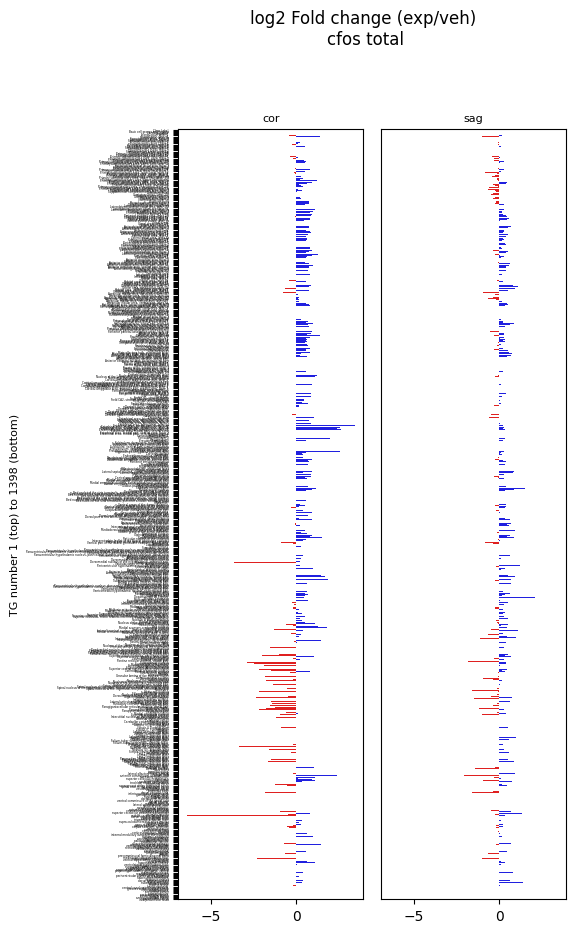

In [156]:
def draw_fold( _df_fold, _color):
    plt.clf()
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(5, 10), sharey=True, gridspec_kw={'wspace': 0.1})

    fig.suptitle(f'log2 Fold change (exp/veh) \n{_color}', fontsize=12, y=1.0)
    #fig.subplots_adjust(top= 2.0)
    
    _df_fold_color = _df_fold[_df_fold.columns[_df_fold.columns.to_series().str.endswith("_"+_color)]] 
    _df_fold_color.columns = ['cor','sag']
    
    colors = ['b' if e >= 0 else 'r' for e in _df_fold_color['cor'].values]
    
    g = sns.barplot(ax = ax1, data = _df_fold_color, y=_df_fold_color.index, x="cor", palette=colors)
    ax1.set_ylabel("")
    ax1.set_xlabel("")
    ax1.set_title('cor',fontsize=8)
    ax1.set_ylabel("TG number 1 (top) to 1398 (bottom)",fontsize=8)
    _index_ids = []
    _index_names = []
    for _i in range(len(_df_fold_color.index)):
        if _i % 2 == 0:
            _index_ids.append(_i)
            _index_names.append(list(_df_fold_color.index.values)[_i])
    
    ax1.set_yticks(_index_ids)
    ax1.set_yticklabels(_index_names, fontsize=2)
    ax1.tick_params(axis='y', labelright=False, right=False)
    
    
    colors = ['b' if e >= 0 else 'r' for e in _df_fold_color['sag'].values]
    sns.barplot(ax = ax2, data = _df_fold_color, y=_df_fold_color.index, x="sag",palette=colors, clip_on=False)
    ax2.set_title('sag',fontsize=8)
    ax2.set_ylabel("")
    ax2.set_xlabel("")
    ax2.set_yticks(_index_ids)
    ax2.set_yticklabels(_index_names, fontsize=2)
    ax2.tick_params(axis='y', labelleft=False, left=False, labelright=False, right=False)
    
    xmax = max(ax1.get_xlim()[1], ax2.get_xlim()[1])
    xmin = min(ax1.get_xlim()[0], ax2.get_xlim()[0])
    #xmax = max(np.quantile(_df_fold_color['sag'].values, 0.90),np.quantile(_df_fold_color['cor'].values, 0.90))
    
    ax1.set_xlim(xmax=xmax,xmin=xmin)
    ax2.set_xlim(xmax=xmax,xmin=xmin)
    #print(xmin,xmax)
    
    #plt.tight_layout()
    #plt.show()
    fig.savefig(f'output/fold_{_color.replace("/","_").replace(" ","_")}.pdf', format='pdf', bbox_inches="tight")



#fig, axes = plt.subplots(1, 3,figsize=(15,10), sharey=True)

for _color_index, _color in enumerate(sorted(color_list)):
    logger.info(_color)
    draw_fold(_df_fold, _color)
#plt.show()
#plt.tight_layout()
#fig.savefig('output/boxplot.pdf')

In [569]:
status = subprocess.check_output('zip /disk2/2024_mice/fold.zip /disk2/2024_mice/fold_*', shell=True)
status = subprocess.check_output('cp /disk2/2024_mice/fold.zip output', shell=True)
print(status)

b''


<Figure size 640x480 with 0 Axes>

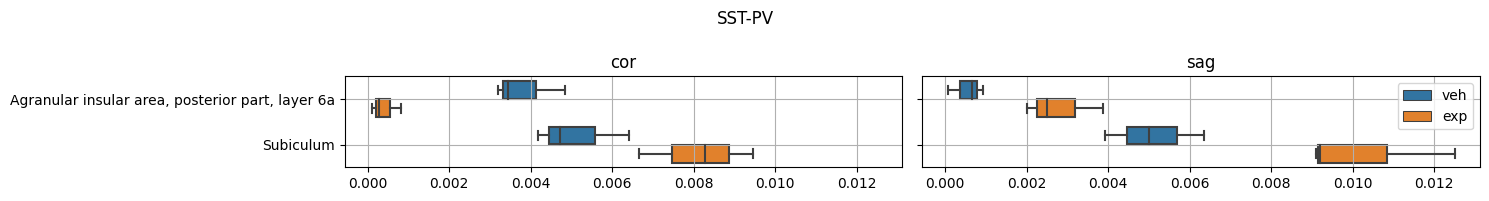

/tmp/ipykernel_3015095/386965231.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


<Figure size 640x480 with 0 Axes>

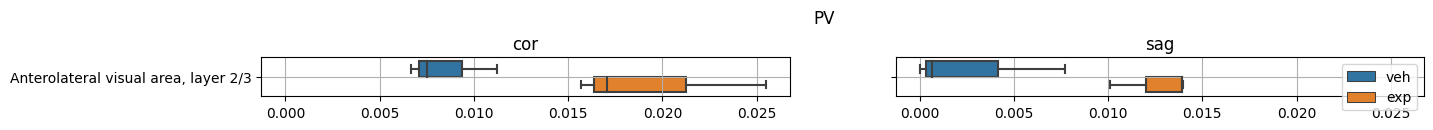

SST/cfos fraction


/tmp/ipykernel_3015095/386965231.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


<Figure size 640x480 with 0 Axes>

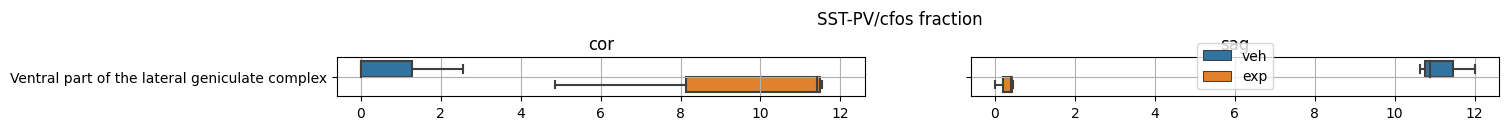

<Figure size 640x480 with 0 Axes>

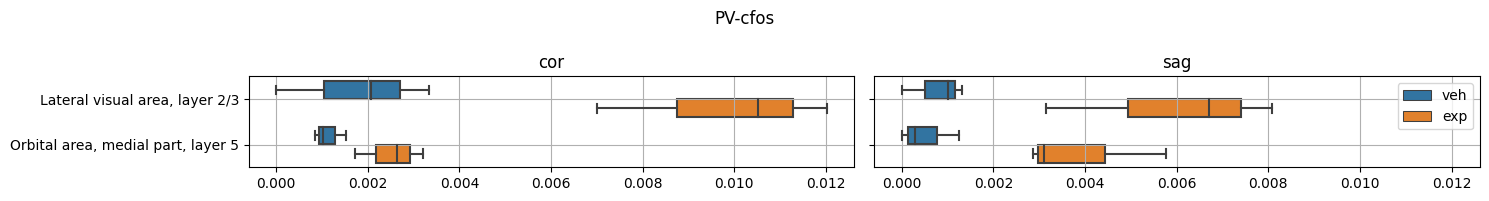

<Figure size 640x480 with 0 Axes>

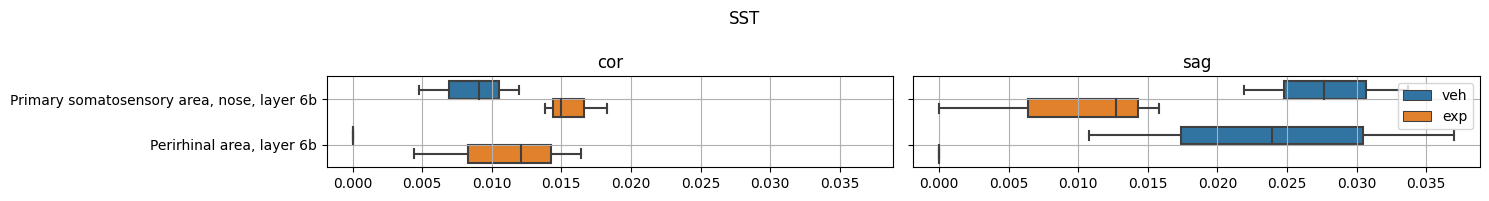

<Figure size 640x480 with 0 Axes>

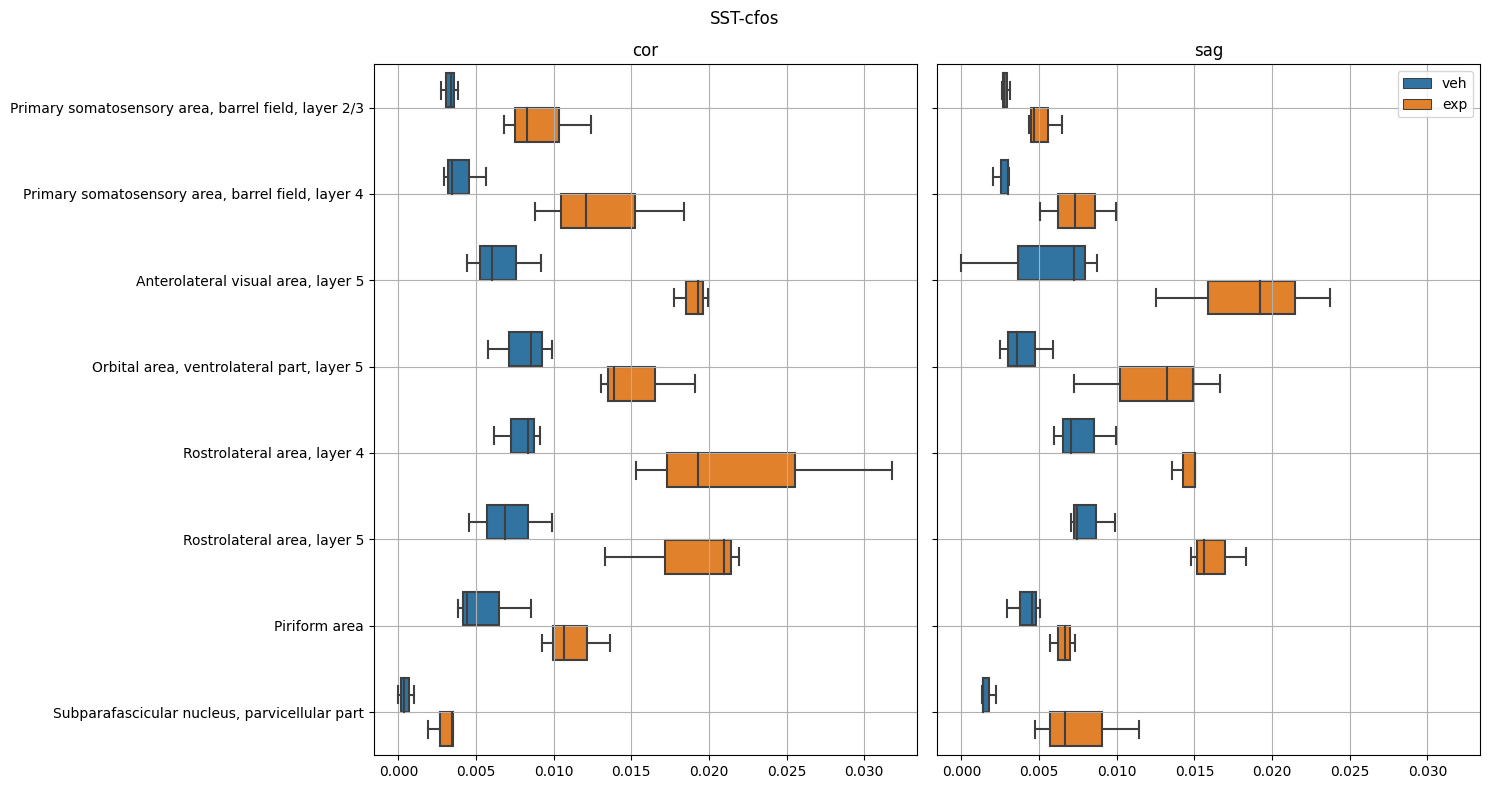

SST-PV-cfos


<Figure size 640x480 with 0 Axes>

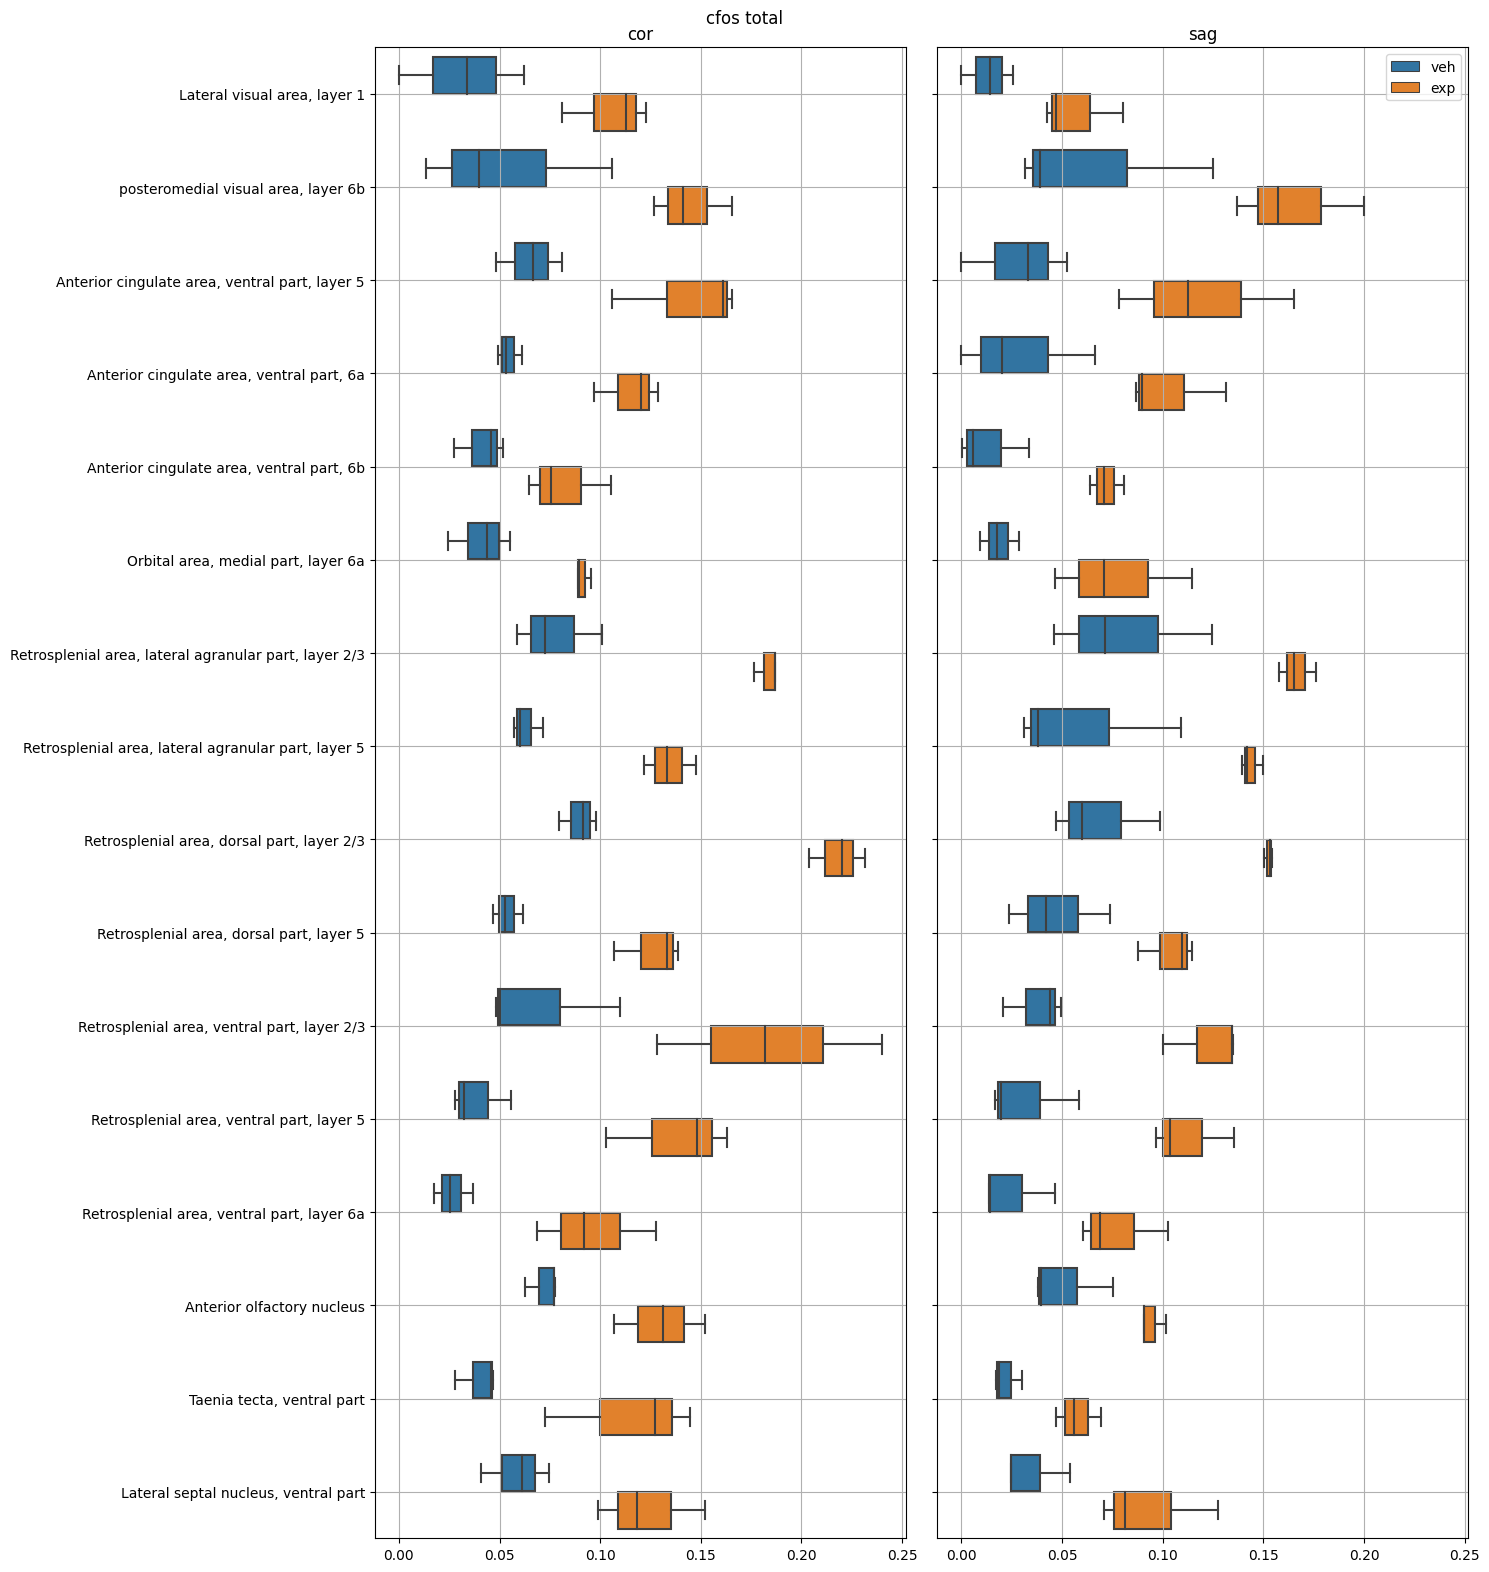

<Figure size 640x480 with 0 Axes>

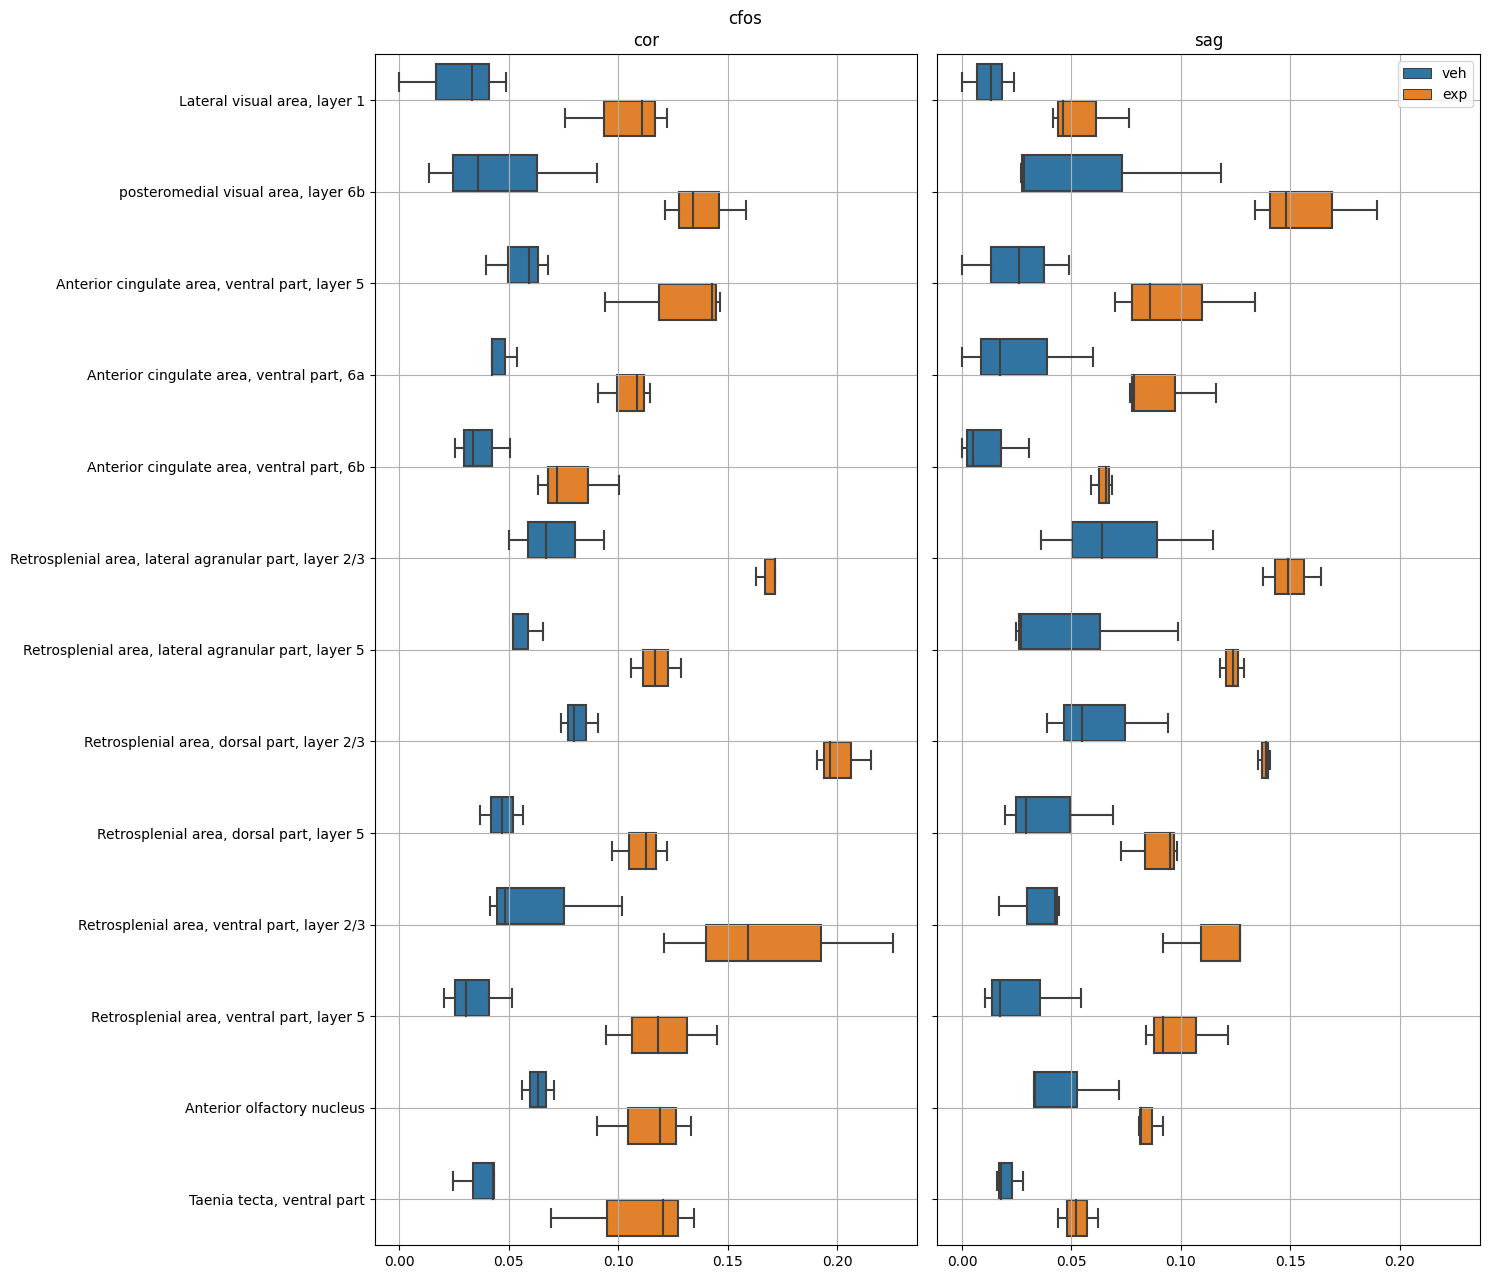

<Figure size 640x480 with 0 Axes>

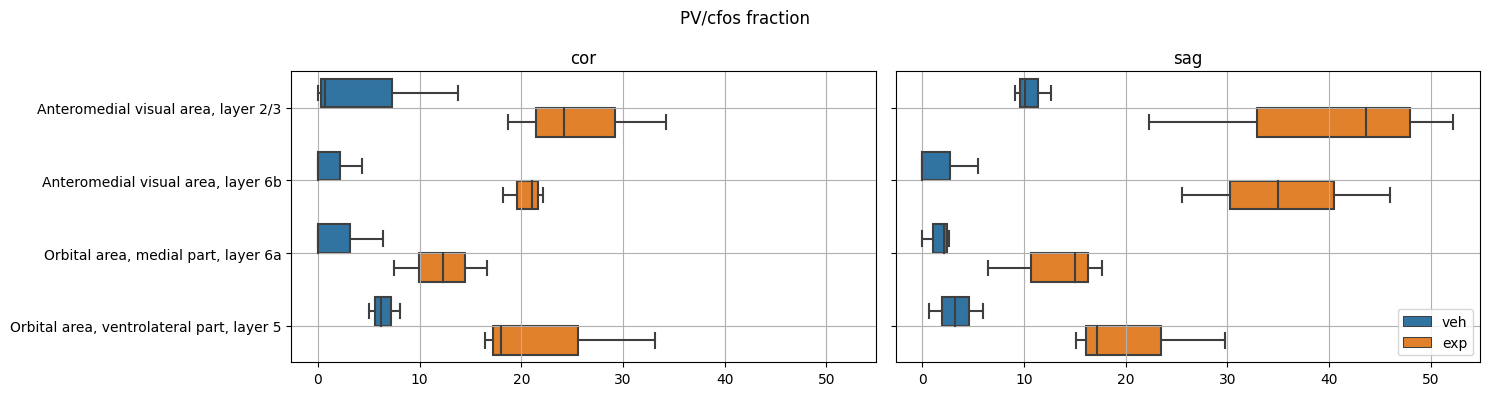

In [568]:
# box plot
_cut_method = 'cor'
min_pvalue = 0.05
#for _cut_method in cut_method_list:

for _color in color_list:

    _ttest_df_filtered = _ttest_df.query(f'color == "{_color}"')
    if len(_ttest_df_filtered) == 0:
        print(_color)
        continue
    _region_id_list = list(set(_ttest_df_filtered['tg_number'].values))
    _tg_number_list = []
    for _r, _g in _ttest_df_filtered.groupby('tg_number'):    
        if _g[_g['cut_method'] == 'cor']['pvalue'].values[0] <= min_pvalue and _g[_g['cut_method'] == 'sag']['pvalue'].values[0] <= min_pvalue:
            _tg_number_list.append(_g['tg_number'].values[0])
        #if True:
        #    break
    if len(_tg_number_list) == 0:
        print(_color)
        continue
    _cut_method = 'cor'
    _df = df_total[df_total.index.str.endswith(_cut_method+"_"+_color)]
    _df = _df[_tg_number_list + ['veh_exp']]
    _df_melt = pd.melt(_df, id_vars=['veh_exp'], value_vars=_tg_number_list)
    _df_melt['TG number'] = _df_melt['TG number'].replace(tg_2_name)
    
    

    plt.clf()  
    #fig = plt.figure(figsize=(10,len(_region_id_list)*1.0))
    fig, axes = plt.subplots(1, 2,figsize=(15,len(_tg_number_list)*1.0), sharey=True, sharex=True)
    fig.suptitle(_color)
    fig.subplots_adjust(top= 0.5)
    
    sns.boxplot(ax=axes[0], y = 'TG number', 
            x = 'value', 
            hue = 'veh_exp', data=_df_melt)
    axes[0].set(title =f'{_cut_method}' , xlabel='', ylabel=f'')
    axes[0].yaxis.grid(True) # Hide the horizontal gridlines
    axes[0].xaxis.grid(True) # Show the vertical gridlines
    #handles, labels = axes[0].get_legend_handles_labels()
    #axes[0].legend(handles, ['veh', 'exp'], title="") 

    axes[0].legend_ = None
    
    _cut_method = 'sag'
    _df = df_total[df_total.index.str.endswith(_cut_method+"_"+_color)]
    _df = _df[_tg_number_list + ['veh_exp']]
    _df_melt = pd.melt(_df, id_vars=['veh_exp'], value_vars=_tg_number_list)
    _df_melt['TG number'] = _df_melt['TG number'].replace(tg_2_name)
    
    sns.boxplot(ax=axes[1], y = 'TG number', 
            x = 'value', 
            hue = 'veh_exp', data=_df_melt)
    axes[1].set(title =f'{_cut_method}' , xlabel='', ylabel=f'')
    axes[1].yaxis.grid(True) # Hide the horizontal gridlines
    axes[1].xaxis.grid(True) # Show the vertical gridlines
    handles, labels = axes[1].get_legend_handles_labels()
    axes[1].legend(handles, ['veh', 'exp'], title="") 

    xmax = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])
    axes[0].set_xlim(xmax=xmax)
    axes[1].set_xlim(xmax=xmax)
    
    #plt.xticks(rotation=90)
    
    #fig.suptitle(f'{_region_id}\n', fontsize=15)
    #fig.tight_layout(h_pad=2.0)#reduces the horizontal gap
    #fig.savefig(f'output/box_{dept_col}.pdf', format='pdf', bbox_inches="tight")
    fig.tight_layout()
    fig.savefig(f'/disk2/2024_mice/boxplot_{_color.replace("/","_").replace(" ","_")}.pdf', format='pdf', bbox_inches="tight")
    plt.show()
    #if True:
    #    break


In [570]:
status = subprocess.check_output('zip /disk2/2024_mice/boxplot.zip /disk2/2024_mice/boxplot_*', shell=True)
status = subprocess.check_output('cp /disk2/2024_mice/boxplot.zip output', shell=True)
print(status)

b''


In [ ]:
df_exp = df_exp[df_exp[df_exp.columns[3:]].sum(axis=1) != 0.0]

In [ ]:
df_exp.loc[ df_exp.eq(0).sum(axis=1).index,'zero_count'] = df_exp.eq(0).sum(axis=1).values

In [ ]:
df_exp[[a for a in df_exp.columns if cut+"_"+color in a]].eq(0).sum(axis=1)

In [ ]:
_df_list = []
_df_columns = []
_df_list.append(df_exp[df_exp.columns[:3]])
_df_columns.extend(df_exp.columns[:3])
for cut in cut_method_list:
    for color in color_list:
        #_row = {}
        _df_columns.append(cut+"_"+color)
        _df_list.append(df_exp[[a for a in df_exp.columns if a.endswith(cut+"_"+color)]].eq(0).sum(axis=1))
        #_row_list.append(_row)
_df_zero_count = pd.concat(_df_list, axis=1)
_df_zero_count.columns = _df_columns
_df_zero_count

In [ ]:
_df_zero_count[(_df_zero_count == 3).sum(axis=1) != 0]

In [ ]:
import urllib.request, json 
with urllib.request.urlopen("http://api.brain-map.org/api/v2/structure_graph_download/1.json") as url:
    mouse_graph = json.load(url)
    #print(data)

In [ ]:
json.dumps(mouse_graph).strip()

In [ ]:
type(mouse_graph['msg'])

In [ ]:
import networkx as nx
G = nx.DiGraph()
def _traverse(G, _parent, _cur):
    #print(_root)

    _name = _cur['name']
    _id = int(_cur['id'])
    G.add_node(_id, name =_name)
    
    if _parent is not None:
        G.add_edge(int(_parent['id']), _id)

    
    if 'children' not in _cur:
        return
        
    _obj_list = _cur['children']
    for _obj in _obj_list:
        
        _traverse(G, _cur, _obj)

_traverse(G, None, mouse_graph['msg'][0])
G

In [ ]:
nx.ancestors(G, 68)

In [ ]:
nx.is_directed_acyclic_graph(G)

dict(nx.tree_all_pairs_lowest_common_ancestor(G, pairs=[(1, 4), (2, 3)]))

In [ ]:
#G.number_of_nodes()

for _c in G.neighbors(879):
    print(G.nodes[_c]['name'])

In [ ]:
from jsonpath_ng import jsonpath, parse
jsonpath_expr = parse('foo[*].baz')
[match.value for match in jsonpath_expr.find(mouse_graph)]

In [ ]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']

In [ ]:
from pprint import pprint

import numpy as np

from brainglobe_atlasapi import BrainGlobeAtlas

bg_atlas = BrainGlobeAtlas("allen_mouse_25um", check_latest=False)

In [ ]:
type(bg_atlas.structures)

In [ ]:
for region_id in _df_zero_count['Region ID'].values:
    try:
        bg_atlas.structures[region_id]["name"]
        #pass
        #logger.info(f'{bg_atlas.structures[region_id]["name"]} / {bg_atlas.get_structure_ancestors(region_id)}')
    except:
        logger.error(f'{region_id}')

#bg_atlas.structures[567]['name']